## **The problem**
Poverty levels in Kenya remain high despite global reports showing a somewhat steady GDP growth.  [The Kenya Poverty Report,2022](https://www.knbs.or.ke/wp-content/uploads/2024/10/The-Kenya-Poverty-Report-2022.pdf), by the Kenya National Bureau of Statistics (KNBS), shows that the national poverty rate was at 39.8%. Data collected through the periodic Kenya Integrated Household Budget Survey(KIHBS) was used to analyse the different forms of poverty, including economic, Nutritional, cultural and multidimensional poverty, informed by a detailed breakdown of household income and expenditure as primary measures of poverty. The 2026 KIHBS is ongoing while the Kenyan population continues to live in poverty. Despite a GDP growth of 4.9% in 2025, Kenyans are still struggling to make ends meet due to economic poverty.

*   Public debt is increasing.
*   Taxation is at its all time highest.
*   Public services, especially in education and healthcare, are questionable.
*   Food prices have increased by about 7.3%.
*   Unemployment rate amongst the working-age population remains high.

I analyse data from the world development indicators to answer the following questions:

1.   To what extent has Kenya’s GDP growth translated into improved economic well-being
2.   Why might poverty remain high despite positive GDP growth?

# **Description of Dataset**

I will use the World Development Indicators (WDI) datasets, compiled by the World Bank, which is a comprehensive collection of global development statistics covering economic, social, environmental, and institutional indicators, such as GDP, poverty rates, education levels, and health outcomes, collected from national statistical agencies, international organisations, and standardised surveys. These datasets contain both country-reported data, administrative records, and globally harmonised estimation methods to ensure comparability across countries and over time. Researchers, policymakers, and analysts use WDI data to track development progress, compare countries, inform policy decisions, and conduct empirical research on issues like poverty, inequality, and economic growth. The WDI datasets are publicly available on the [World Bank Data Catalogue](https://databank.worldbank.org/source/world-development-indicators#). For the scope of my project, I filtered the data for Kenya.


In [1]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

In [2]:
df=pd.read_csv("/content/wdi001.csv",delimiter=',')

In [3]:
#renaming the columns I am interested in using for my analysis.
df.rename(columns={"GDP Growth Rate":"GDPRate"},inplace=True)
df.rename(columns={"Youth Literacy Rate":"YouthLiteracy"},inplace=True)
df.rename(columns={"Population Aged 15-64":"WorkingPopulation"},inplace=True)
df.rename(columns={"Unemployment Rate":"UnemploymentRate"},inplace=True)

#Filtering data to use only data from Kenya.
data=df.loc[df['Country'] == 'Kenya']
display(data[['GDPRate','YouthLiteracy','UnemploymentRate','WorkingPopulation']])

,GDPRate,YouthLiteracy,UnemploymentRate,WorkingPopulation
1972,9.457359,NaN,NaN,3959719.0
1973,4.964467,NaN,NaN,4259655.0
1974,7.959224,NaN,NaN,5065242.0
1975,22.173892,NaN,NaN,5431441.0
1976,17.082429,NaN,NaN,5609652.0
...,...,...,...,...
11795,6.472494,NaN,2.680,19815585.0
11796,0.232283,NaN,2.756,21176475.0
11797,5.121106,NaN,2.704,23276813.0
11798,5.020111,86.525627,2.768,25425717.0


In [4]:
data.describe()

,Year,GDP Total,GDPRate,GDP Per Capita,YouthLiteracy,Adult Literacy Rate,Primary School Enrollment,Secondary School Enrollment,Tertiary School Enrollment,Labor Force Female,Labor Force Male,Labor Force Total,UnemploymentRate,Life Expectancy,Population Aged 0-14,WorkingPopulation,Population Aged 65-up,Population Total,Female Population,Male Population
count,65.00000,6.500000e+01,64.000000,65.000000,4.000000,4.000000,43.000000,30.000000,26.000000,35.000000,35.000000,35.000000,34.000000,64.000000,6.500000e+01,6.500000e+01,6.500000e+01,6.500000e+01,65.000000,65.000000
mean,1992.00000,2.606443e+10,4.625664,650.994187,89.411497,78.942516,99.223488,33.994615,2.975067,69.054943,75.154486,72.066857,3.352912,57.769016,1.219485e+07,1.436022e+07,6.404335e+05,2.719550e+07,50.380956,49.619044
std,18.90767,3.487054e+10,4.329251,616.068744,6.066917,4.862739,14.198923,12.142304,3.571005,3.198102,1.639712,2.373729,1.056196,3.718366,5.568170e+06,9.017879e+06,4.057923e+05,1.490894e+07,0.136273,0.136273
min,1960.00000,7.912655e+08,-7.774635,99.271696,82.390472,72.157028,59.709991,17.325439,0.743430,62.108000,71.394000,66.716000,2.650000,48.477000,3.749423e+06,3.699624e+06,2.403890e+05,7.695307e+06,50.164822,49.476280
25%,1976.00000,3.474542e+09,2.267533,241.224426,85.491838,77.089037,94.584171,23.618650,0.877407,69.981000,74.641000,72.439000,2.765000,55.573250,7.266829e+06,6.402798e+06,2.879960e+05,1.395762e+07,50.239517,49.490858
50%,1992.00000,8.283115e+09,4.451357,391.238771,89.762814,80.366520,103.370277,33.824699,1.149090,70.418000,75.507000,72.874000,2.853000,58.090500,1.186647e+07,1.198816e+07,5.278290e+05,2.438246e+07,50.447083,49.552917
75%,2008.00000,3.589515e+10,6.003627,915.544355,93.682472,82.219999,107.959042,41.361045,2.896330,70.907500,76.251000,73.410000,2.979250,60.745250,1.720431e+07,2.117648e+07,8.255620e+05,3.920635e+07,50.509142,49.760483
max,2024.00000,1.244987e+11,22.173892,2206.134979,95.729889,82.879997,116.448082,57.870560,11.886210,71.417000,77.454000,74.405000,5.707000,63.646000,2.078767e+07,3.397138e+07,1.673896e+06,5.643294e+07,50.523720,49.835178


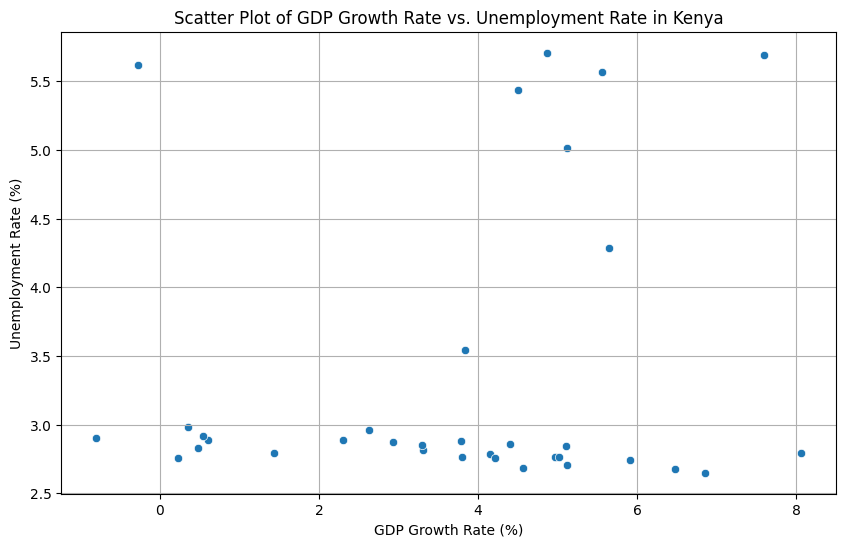

In [5]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDPRate', y='UnemploymentRate', data=data,)
plt.title('Scatter Plot of GDP Growth Rate vs. Unemployment Rate in Kenya')
plt.xlabel('GDP Growth Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()

The plot shows an overall negative correlation between GDP growth and unemployment in Kenya. As the GDP Growth Rate increases towards the right on the x-axis, the Unemployment Rate decreases along the y-axis. This implies that periods of stronger economic growth are associated with lower unemployment rates. Conversely, when the GDP Growth Rate is lower, the Unemployment Rate appears higher. This confirms typical observations in macroeconomic relationships, such as Okun's laws.


Using the equation of a straight line for my data, I assume the following relationship:
**UnemploymentRate=m*GDPRate**.



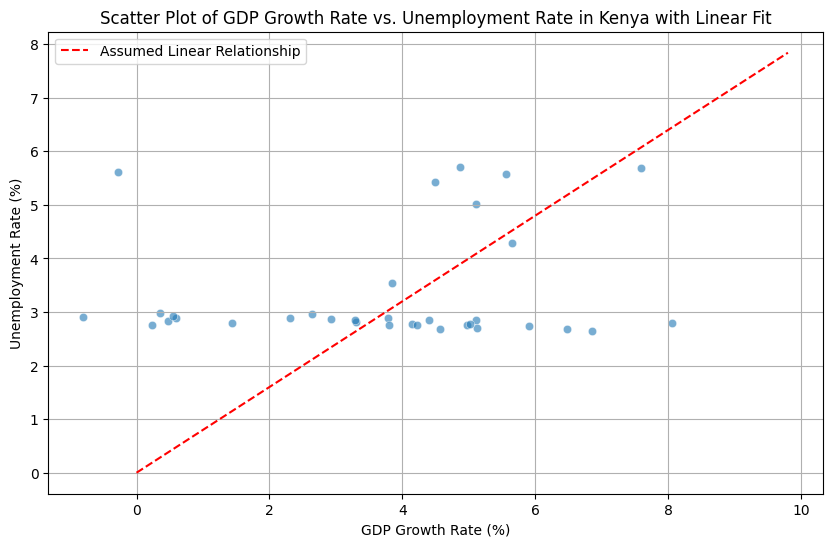

In [6]:
import numpy as np
m = 0.8
GDPRate = np.arange(0, 10, step=0.2)
UnemploymentRate = m * GDPRate

plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDPRate', y='UnemploymentRate', data=data, alpha=0.6)
plt.plot(GDPRate, UnemploymentRate, color='red', linestyle='--', label='Assumed Linear Relationship')
plt.title('Scatter Plot of GDP Growth Rate vs. Unemployment Rate in Kenya with Linear Fit')
plt.xlabel('GDP Growth Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# Dropping rows with NaN values in 'GDPRate' or 'UnemploymentRate' for a more accurate regression
clean_data = data.dropna(subset=['GDPRate', 'UnemploymentRate'])

X = clean_data['GDPRate'].values
y = clean_data['UnemploymentRate'].values

X_with_intercept = np.vstack([X, np.ones(len(X))]).T

coefficients = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
m_best_fit = coefficients[0]
c_intercept = coefficients[1]

print(f"The slope 'm' for the line of best fit is: {m_best_fit:.4f}")
print(f"The y-intercept 'c' for the line of best fit is: {c_intercept:.4f}")

The slope 'm' for the line of best fit is: 0.0750
The y-intercept 'c' for the line of best fit is: 3.0738


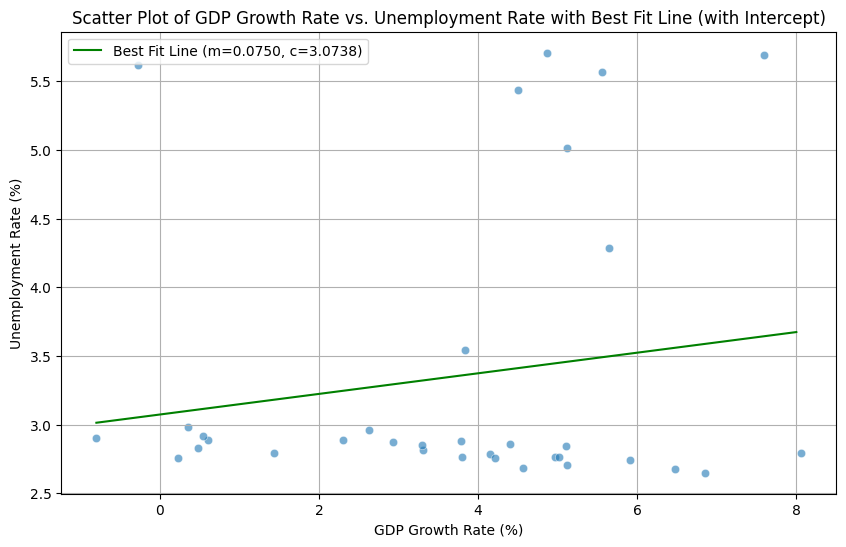

In [8]:
# Updated plot with the calculated best fit 'm' and 'c'
GDPRate_plot = np.arange(clean_data['GDPRate'].min(), clean_data['GDPRate'].max(), step=0.1)
UnemploymentRate_best_fit = m_best_fit * GDPRate_plot + c_intercept

plt.figure(figsize=(10, 6))
sns.scatterplot(x='GDPRate', y='UnemploymentRate', data=clean_data, alpha=0.6)
plt.plot(GDPRate_plot, UnemploymentRate_best_fit, color='green', linestyle='-', label=f'Best Fit Line (m={m_best_fit:.4f}, c={c_intercept:.4f})')
plt.title('Scatter Plot of GDP Growth Rate vs. Unemployment Rate with Best Fit Line (with Intercept)')
plt.xlabel('GDP Growth Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
from statsmodels.formula.api import ols
model=ols('UnemploymentRate~GDPRate',data=data).fit()
print(model.params)

Intercept    3.073778
GDPRate      0.074989
dtype: float64


# **Interpretation of results**
The OLS tool from statsmodels confirms the calculated values of the intercept(3.073778) and the slope(0.075).
A value of m=0.075 suggests that for every 1% increase in GDP Growth Rate, the Unemployment Rate is predicted to increase by approximately 0.075 percentage points. This is a positive correlation, suggesting that higher GDP growth is associated with a slight increase in unemployment in this specific model, which contradicts the initial visual observation of a negative correlation. This might indicate that the linear model isn't the best fit for this situation or that there are other confounding factors not included in this simple regression.

Using the second dataset. I explore other social indicators that were not included in the first dataset and whether different indicators have varying levels of importance when it comes to measuring poverty levels. I will use a Random Forest Regression in this case.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

In [11]:
data=pd.read_csv("/content/WDIKenya_Data.csv")
data.head()

,Country Name,Country Code,Series Name,Series Code,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Kenya,KEN,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,73.781,68.182,66.659,63.656,59.38,59.513,57.272,56.313,54.498,..
1,Kenya,KEN,"Agriculture, forestry, and fishing, value adde...",NV.AGR.TOTL.ZS,20.0345164328349,20.8936374065292,20.314910419968,20.8611638110686,22.7027261604451,21.4770750957252,21.0361920649933,21.4522060902205,22.4728462758555,..
2,Kenya,KEN,"Annual freshwater withdrawals, total (% of int...",ER.H2O.FWTL.ZS,19.4782608695652,19.4782608695652,19.4782608695652,19.4782608695652,19.4782608695652,19.4782608695652,19.4782608695652,..,..,..
3,Kenya,KEN,Births attended by skilled health staff (% of ...,SH.STA.BRTC.ZS,70.2,..,..,..,..,..,..,..,..,..
4,Kenya,KEN,"Contraceptive prevalence, any method (% of mar...",SP.DYN.CONU.ZS,61.1741487617736,59.9682382404727,61.9209893809262,59.8006521261165,65.1162106221682,64.7,62.5,..,..,..


In [12]:
#Changing the layout so that the indicators become the columns and the years represent the rows.

df = data[data['Country Name'].eq('Kenya')].copy()

year_cols = [c for c in df.columns if '[YR' in c]

long = df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)

long['year'] = long['year'].str.extract(r'(\d{4})').astype(int)
long['value'] = long['value'].replace('..', np.nan)
long['value'] = pd.to_numeric(long['value'], errors='coerce')

wide = long.pivot_table(index='year', columns='Series Name', values='value', aggfunc='first').reset_index()
wide = wide.sort_values('year').reset_index(drop=True)

print('Cleaned shape:', wide.shape)
wide.head(10)

Cleaned shape: (10, 52)


Series Name,year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Agriculture, forestry, and fishing, value added (% of GDP)","Annual freshwater withdrawals, total (% of internal resources)",Births attended by skilled health staff (% of total),"Contraceptive prevalence, any method (% of married women ages 15-49)",Domestic credit provided by financial sector (% of GDP),Electric power consumption (kWh per capita),Energy use (kg of oil equivalent per capita),Exports of goods and services (% of GDP),"External debt stocks, total (DOD, current US$)","Fertility rate, total (births per woman)","Foreign direct investment, net inflows (BoP, current US$)",Forest area (sq. km),GDP (current US$),GDP growth (annual %),"GNI per capita, Atlas method (current US$)","GNI per capita, PPP (current international $)","GNI, Atlas method (current US$)","GNI, PPP (current international $)",Gross capital formation (% of GDP),High-technology exports (% of manufactured exports),"Immunization, measles (% of children ages 12-23 months)",Imports of goods and services (% of GDP),Income share held by lowest 20%,"Industry (including construction), value added (% of GDP)","Inflation, GDP deflator (annual %)","Life expectancy at birth, total (years)",Merchandise trade (% of GDP),Military expenditure (% of GDP),Mobile cellular subscriptions (per 100 people),"Mortality rate, under-5 (per 1,000 live births)",Net barter terms of trade index (2015 = 100),Net migration,Net official development assistance and official aid received (current US$),"Personal remittances, received (current US$)",Population density (people per sq. km of land area),Population growth (annual %),"Population, total",Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population),Poverty headcount ratio at national poverty lines (% of population),"Prevalence of HIV, total (% of population ages 15-49)","Prevalence of underweight, weight for age (% of children under 5)","Primary completion rate, total (% of relevant age group)","Revenue, excluding grants (% of GDP)","School enrollment, primary (% gross)","School enrollment, secondary (% gross)",Surface area (sq. km),Tax revenue (% of GDP),Terrestrial and marine protected areas (% of total territorial area),"Total debt service (% of exports of goods, services and primary income)",Urban population growth (annual %)
0,2016,73.781,20.034516,19.478261,70.2,61.174149,51.507770,173.266602,533.407779,13.249745,2.105767e+10,3.689,4.695333e+08,35519.7,7.481514e+10,4.213517,1490.0,3860.0,7.174826e+10,1.860003e+11,19.348436,7.586234,93.0,21.615275,NaN,18.162159,5.849629,62.526,26.467903,1.247310,80.977236,45.5,97.4,-29728.0,2.188385e+09,1.744639e+09,84.005777,2.207757,48139687.0,NaN,NaN,4.5,13.0,102.20024,19.065776,104.114853,74.469859,580370.0,14.966473,10.5,11.173638,1.944121
1,2017,68.182,20.893637,19.478261,NaN,59.968238,51.156988,175.597404,538.606904,12.736660,2.695135e+10,3.609,1.346085e+09,35815.3,8.203651e+10,3.837958,1540.0,4100.0,7.569196e+10,2.016007e+11,20.663495,3.348590,84.0,23.258398,NaN,17.503509,7.581934,62.725,27.346360,1.237594,87.026531,44.7,100.7,-68702.0,2.480222e+09,1.962273e+09,85.560119,2.174129,49197766.0,NaN,NaN,4.3,NaN,NaN,21.145872,101.957891,NaN,580370.0,15.052464,10.5,14.597444,1.819993
2,2018,66.659,20.314910,19.478261,NaN,61.920989,49.306547,178.142110,546.495297,12.541975,3.143380e+10,3.536,7.677615e+08,36110.9,9.220298e+10,5.647946,1720.0,4350.0,8.658904e+10,2.181510e+11,19.375986,3.612963,92.0,21.872778,NaN,17.313146,4.215028,62.825,25.411326,1.207385,98.594468,43.7,95.8,-115436.0,2.491010e+09,2.720366e+09,87.019449,2.030837,50207107.0,NaN,NaN,4.1,NaN,NaN,18.678934,99.770420,NaN,580370.0,14.361279,10.5,23.699506,1.572054
3,2019,63.656,20.861164,19.478261,NaN,59.800652,49.032865,175.810605,543.883187,11.427996,3.497010e+10,3.433,4.699403e+08,36110.9,1.003784e+11,5.114159,1880.0,4610.0,9.615446e+10,2.361699e+11,19.341832,4.593278,92.0,20.331466,NaN,16.930545,4.275234,62.939,23.405425,1.112571,106.547822,42

In [13]:
# Selecting the poverty target variable

national_poverty = 'Poverty headcount ratio at national poverty lines (% of population)'
poverty_3usd = 'Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)'

target = national_poverty if national_poverty in wide.columns else poverty_3usd
print('Selected target:', target)

wide[['year', 'GDP growth (annual %)', target]]

Selected target: Poverty headcount ratio at national poverty lines (% of population)


Series Name,year,GDP growth (annual %),Poverty headcount ratio at national poverty lines (% of population)
0,2016,4.213517,NaN
1,2017,3.837958,NaN
2,2018,5.647946,NaN
3,2019,5.114159,NaN
4,2020,-0.272766,42.9
5,2021,7.590489,38.6
6,2022,4.859981,39.8
7,2023,5.719992,NaN
8,2024,4.724740,NaN
9,2025,NaN,NaN


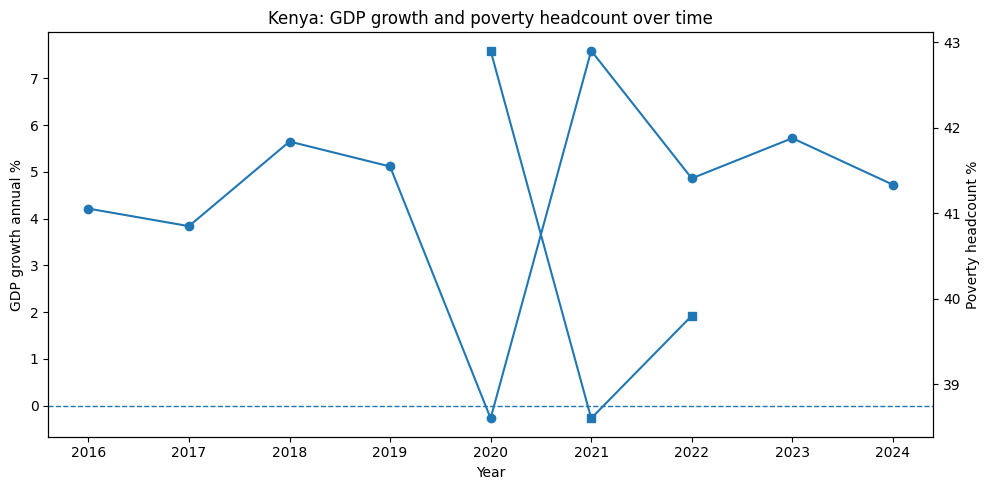

In [14]:
# Plot of GDP growth vs poverty over time
plot_df = wide[['year', 'GDP growth (annual %)', target]].dropna(subset=['GDP growth (annual %)'])

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(plot_df['year'], plot_df['GDP growth (annual %)'], marker='o', label='GDP growth (%)')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP growth annual %')
ax1.axhline(0, linestyle='--', linewidth=1)

ax2 = ax1.twinx()
poverty_df = plot_df.dropna(subset=[target])
ax2.plot(poverty_df['year'], poverty_df[target], marker='s', label='Poverty headcount (%)')
ax2.set_ylabel('Poverty headcount %')

plt.title('Kenya: GDP growth and poverty headcount over time')
fig.tight_layout()
plt.show()

In [23]:

# There are very few poverty observations, selecting features with enough data

exclude_keywords = ['Poverty headcount']
exclude_cols = ['year', target]

candidate_features = [
    c for c in wide.columns
    if c not in exclude_cols and not any(k in c for k in exclude_keywords)
]
min_non_missing = int(np.ceil(0.70 * len(wide)))
features = [c for c in candidate_features if wide[c].notna().sum() >= min_non_missing]

model_df = wide[['year', target] + features].dropna(subset=[target]).copy()

print('Rows available for poverty modelling:', len(model_df))
print('Number of candidate features:', len(features))
model_df[['year', target]].head()

Rows available for poverty modelling: 3
Number of candidate features: 44


Series Name,year,Poverty headcount ratio at national poverty lines (% of population)
4,2020,42.9
5,2021,38.6
6,2022,39.8


In [24]:
#Selecting top features before modelling

correlations = []
for col in features:
    temp = model_df[[target, col]].dropna()
    if len(temp) >= 3 and temp[col].nunique() > 1:
        correlations.append((col, temp[target].corr(temp[col])))

corr_df = pd.DataFrame(correlations, columns=['feature', 'correlation_with_poverty'])
corr_df['absolute_correlation'] = corr_df['correlation_with_poverty'].abs()
corr_df = corr_df.sort_values('absolute_correlation', ascending=False)

top_features = corr_df['feature'].head(6).tolist()
if 'GDP growth (annual %)' in features and 'GDP growth (annual %)' not in top_features:
    top_features = ['GDP growth (annual %)'] + top_features[:5]

print('Selected modelling features:')
for f in top_features:
    print('-', f)

corr_df.head(15)

Selected modelling features:
- Mobile cellular subscriptions (per 100 people)
- GDP growth (annual %)
- Population growth (annual %)
- Total debt service (% of exports of goods, services and primary income)
- Domestic credit provided by financial sector (% of GDP)
- External debt stocks, total (DOD, current US$)


,feature,correlation_with_poverty,absolute_correlation
25,Mobile cellular subscriptions (per 100 people),-0.999139,0.999139
11,GDP growth (annual %),-0.997174,0.997174
32,Population growth (annual %),0.995310,0.995310
39,"Total debt service (% of exports of goods, ser...",0.994558,0.994558
3,Domestic credit provided by financial sector (...,-0.966444,0.966444
7,"External debt stocks, total (DOD, current US$)",-0.935619,0.935619
5,Energy use (kg of oil equivalent per capita),-0.888808,0.888808
1,"Agriculture, forestry, and fishing, value adde...",0.861815,0.861815
23,Merchandise trade (% of GDP),-0.856622,0.856622
4,Electric power consumption (kWh per capita),-0.844616,0.844616


In [17]:
# Training model using Leave-One-Out cross-validation because the dataset is tiny
X = model_df[top_features]
y = model_df[target]

rf_model = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=1,
        random_state=42
    ))
])

rf_model.fit(X, y)

loo = LeaveOneOut()
y_pred_cv = cross_val_predict(rf_model, X, y, cv=loo)

mae = mean_absolute_error(y, y_pred_cv)
r2 = r2_score(y, y_pred_cv) if len(y) > 2 else np.nan

print('Leave-One-Out MAE:', round(mae, 3))
print('Leave-One-Out R-squared:', round(r2, 3))

results = model_df[['year', target]].copy()
results['predicted_poverty'] = y_pred_cv
results['prediction_error'] = results[target] - results['predicted_poverty']
results

Leave-One-Out MAE: 1.992
Leave-One-Out R-squared: -0.705


Series Name,year,Poverty headcount ratio at national poverty lines (% of population),predicted_poverty,prediction_error
4,2020,42.9,39.3944,3.5056
5,2021,38.6,40.6866,-2.0866
6,2022,39.8,40.1824,-0.3824


In [25]:
 #Feature importance from the fitted Random Forest
forest = rf_model.named_steps['model']
importance_df = pd.DataFrame({
    'feature': top_features,
    'importance': forest.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
4,Domestic credit provided by financial sector (...,0.211888
1,GDP growth (annual %),0.192366
0,Mobile cellular subscriptions (per 100 people),0.175491
5,"External debt stocks, total (DOD, current US$)",0.173869
2,Population growth (annual %),0.131521
3,"Total debt service (% of exports of goods, ser...",0.114865


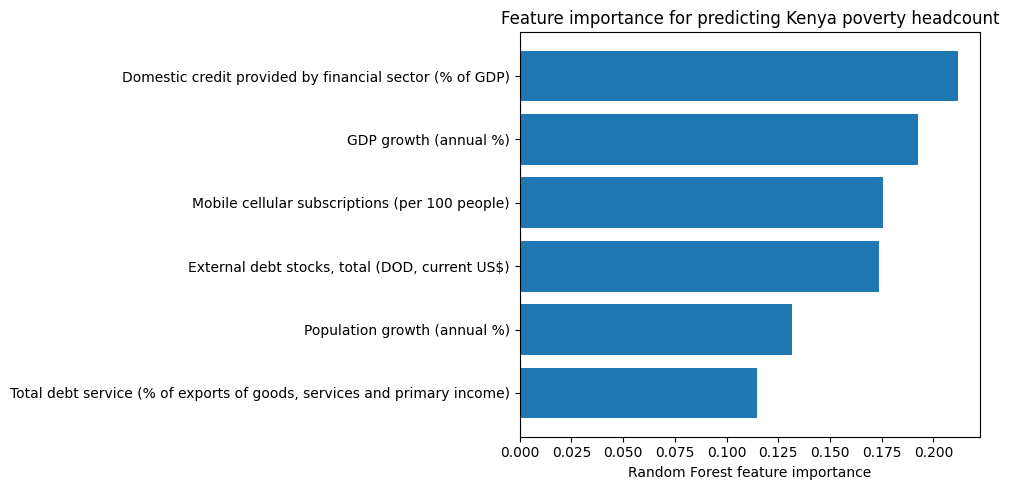

In [19]:
# Plot of feature importance
plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Random Forest feature importance')
plt.title('Feature importance for predicting Kenya poverty headcount')
plt.tight_layout()
plt.show()

# Conclusion
A simple linear regression yielded inconclusive results as it showed GDP growth led to a slight increase in unemployment. This could mean the equation used neeeds to be modified to include other indicators besides GDP Growth Rate and Unemployment Rate.

Similarly, the random forest regression model did not perfom well since my dataset was extremely small. For this reason, the observations in my results are only exploratory and further analysis is needed to better answer the question of why poverty levels in Kenya may remain high despite a growth in GDP

However, both analyis show that GDP Growth alone is not sufficinet in capturing the poverty levels of a country since poverty manifests in diffrent forms besides economic well-being.

Therefore, at a macro-economic level, GDP growth can be used to show a general outlook of a countrys's economic status but it must be backed by supporting evidencee at the micro-economic level. This way, policy-makers, governments, investors etc. can implement interventions that are relevant for the general population and not too high-level.

